In [1]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print(path)

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
/kaggle/input/nasa-cmaps


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Path to dataset files: /kaggle/input/nasa-cmaps


In [6]:
import os

files = os.listdir(path)
print(files)

['CMaps']


In [7]:
data_path = path + "/CMaps"

files = os.listdir(data_path)
print(files)

['RUL_FD002.txt', 'test_FD003.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD004.txt', 'x.txt', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt', 'RUL_FD001.txt', 'RUL_FD004.txt', 'RUL_FD003.txt', 'test_FD001.txt']


In [8]:
columns = ['engine_id','cycle']

for i in range(1,4):
    columns.append(f'setting_{i}')

for i in range(1,22):
    columns.append(f'sensor_{i}')

In [9]:
import pandas as pd

train = pd.read_csv(
    data_path + "/train_FD001.txt",
    sep=" ",
    header=None
)

train = train.iloc[:,:26]
train.columns = columns

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
train.shape

(20631, 26)

In [11]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

train = train.merge(max_cycle, on='engine_id', how='left')
train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [12]:
train[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(10)

,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


In [13]:
train['engine_id'].nunique()

100

In [14]:
engine_1 = train[train['engine_id'] == 1]
engine_1.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


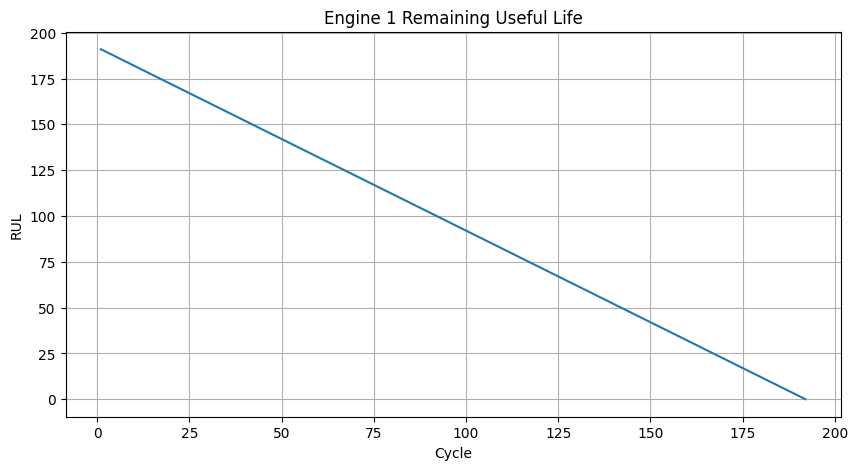

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1 Remaining Useful Life')
plt.grid(True)
plt.show()

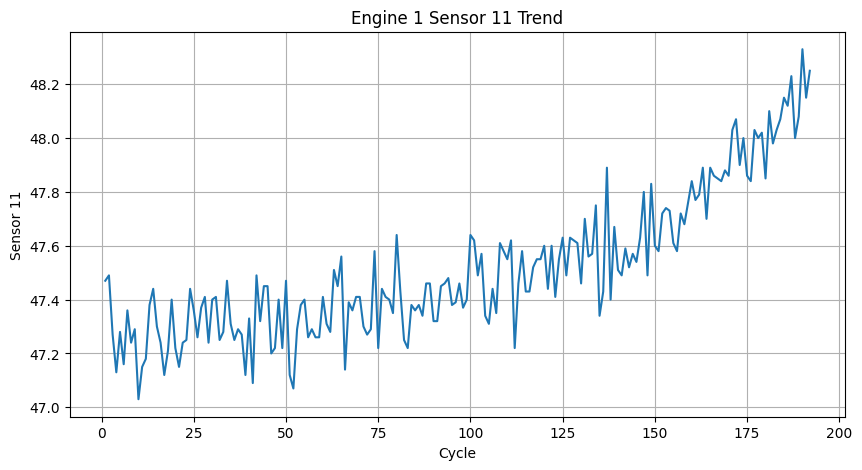

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycle'], engine_1['sensor_11'])
plt.xlabel('Cycle')
plt.ylabel('Sensor 11')
plt.title('Engine 1 Sensor 11 Trend')
plt.grid(True)
plt.show()

In [17]:
drop_cols = ['engine_id', 'cycle', 'max_cycle']
train_data = train.drop(columns=drop_cols)

train_data.head()

,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [19]:
X = train_data.drop(columns=['RUL'])
y = train_data['RUL']

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RandomForest RMSE:", rmse)

RandomForest RMSE: 41.52355692839261


In [25]:
train['RUL'] = train['RUL'].clip(upper=125)

In [26]:
drop_cols = ['engine_id', 'cycle', 'max_cycle']
train_data = train.drop(columns=drop_cols)

X = train_data.drop(columns=['RUL'])
y = train_data['RUL']

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RandomForest RMSE:", rmse)

RandomForest RMSE: 18.760225779525264


In [31]:
!pip install xgboost

In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [33]:
y_pred_xgb = xgb_model.predict(X_test)

In [34]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 18.660971090514437


In [35]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
sensor_11,0.560601
sensor_9,0.131671
sensor_4,0.076979
sensor_12,0.048743
sensor_7,0.025527
sensor_14,0.023024
sensor_15,0.019941
sensor_21,0.017849
sensor_2,0.016034
sensor_3,0.014874


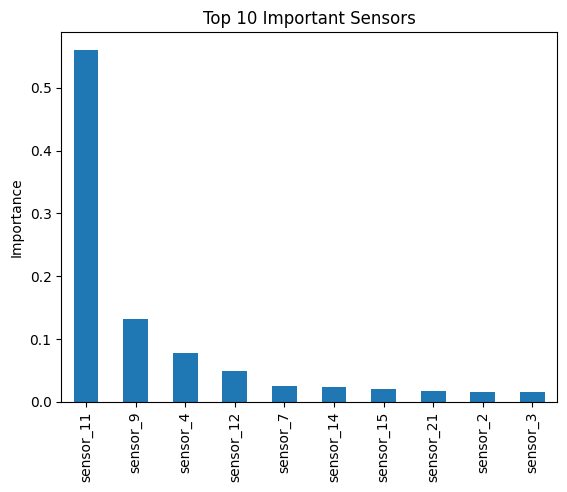

In [36]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Sensors")
plt.ylabel("Importance")
plt.show()

In [37]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
feature_cols = [col for col in train.columns if col not in ['engine_id', 'cycle', 'max_cycle', 'RUL']]
print("feature 개수:", len(feature_cols))
print(feature_cols)

feature 개수: 24
['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [39]:
scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[feature_cols] = scaler.fit_transform(train_scaled[feature_cols])

train_scaled.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.315980,-1.372953,0.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,...,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427,192,125
1,1,2,0.872722,-1.031720,0.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,...,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922,192,125
2,1,3,-1.961874,1.015677,0.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,...,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423,192,125
3,1,4,0.324090,-0.008022,0.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,...,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792,192,125
4,1,5,-0.864611,-0.690488,0.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,...,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552,192,125


In [40]:
def create_sequences(df, feature_cols, seq_length=30):
    X_seq = []
    y_seq = []

    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')

        feature_array = engine_data[feature_cols].values
        rul_array = engine_data['RUL'].values

        for i in range(len(engine_data) - seq_length + 1):
            X_seq.append(feature_array[i:i+seq_length])
            y_seq.append(rul_array[i+seq_length-1])

    return np.array(X_seq), np.array(y_seq)

In [41]:
seq_length = 30

X_seq, y_seq = create_sequences(train_scaled, feature_cols, seq_length=seq_length)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (17731, 30, 24)
y_seq shape: (17731,)


In [42]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

print(X_train_seq.shape, X_test_seq.shape)

(14184, 30, 24) (3547, 30, 24)


In [43]:
lstm_model = Sequential([
    LSTM(64, input_shape=(seq_length, len(feature_cols)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,745 (139.63 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [45]:
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 5218.6602 - mae: 60.9356 - val_loss: 2697.0288 - val_mae: 42.3114
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 1411.1245 - mae: 29.6388 - val_loss: 547.3535 - val_mae: 19.1519
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 396.9362 - mae: 15.9351 - val_loss: 255.4019 - val_mae: 13.0687
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 256.6542 - mae: 12.2899 - val_loss: 167.0650 - val_mae: 10.2515
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 217.1030 - mae: 11.1482 - val_loss: 141.0543 - val_mae: 9.0996
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 199.9716 - mae: 10.6242 - val_loss: 130.1746 - val_mae: 8.7175
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 185.9718 - mae: 10.2598 - val_loss: 124.8857 - val_mae: 8.1536
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 173.1346 - mae: 9.9367 - val_loss: 114.6305 - val_mae: 8.1531

In [46]:
y_pred_lstm = lstm_model.predict(X_test_seq)

rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
print("LSTM RMSE:", rmse_lstm)

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
LSTM RMSE: 5.696240426700693


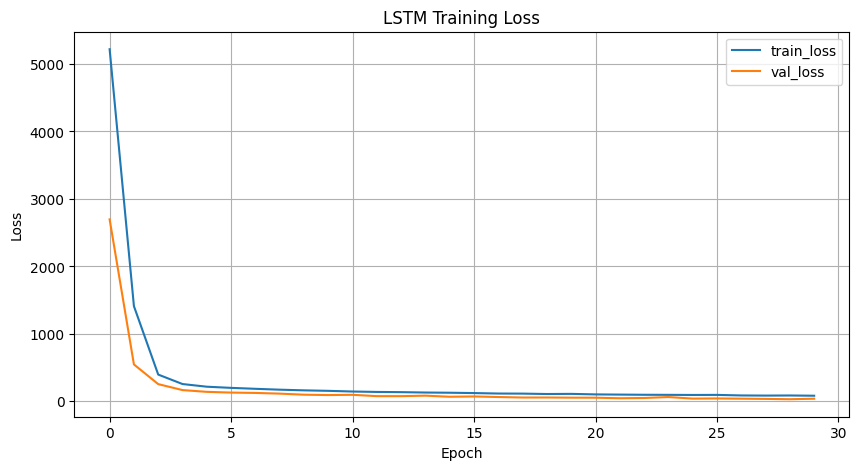

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
results = pd.DataFrame({
    'Model': ['RandomForest', 'XGBoost', 'LSTM'],
    'RMSE': [18.7602, 18.0, rmse_lstm]
})

results


,Model,RMSE
0,RandomForest,18.76020
1,XGBoost,18.00000
2,LSTM,5.69624


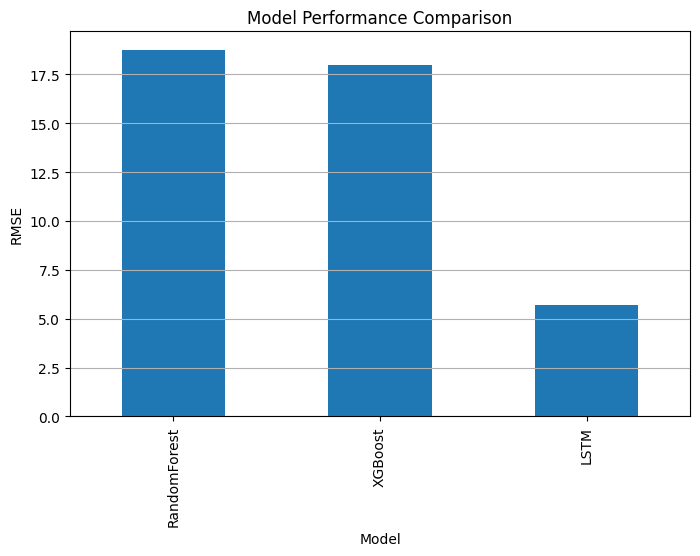

In [52]:
results.plot(x='Model', y='RMSE', kind='bar', legend=False, figsize=(8,5))
plt.title('Model Performance Comparison')
plt.ylabel('RMSE')
plt.grid(axis='y')
plt.show()

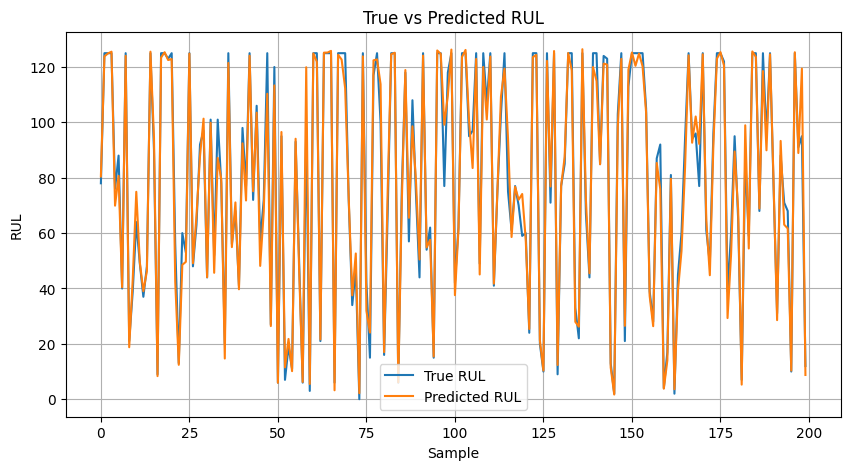

In [55]:
plt.figure(figsize=(10,5))

plt.plot(y_test_seq[:200], label="True RUL")
plt.plot(y_pred_lstm[:200], label="Predicted RUL")

plt.title("True vs Predicted RUL")
plt.xlabel("Sample")
plt.ylabel("RUL")

plt.legend()
plt.grid()

plt.show()

In [56]:
lstm_model.save("lstm_model.h5")

In [58]:
lstm_model.save("lstm_model.keras")

In [59]:
!ls

lstm_model.h5  lstm_model.keras  sample_data


In [60]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [61]:
train_scaled.to_csv("train_scaled_fd001.csv", index=False)

In [62]:
train_scaled.to_csv("train_scaled_fd001.csv", index=False)

In [63]:
!ls

lstm_model.h5	  sample_data  train_scaled_fd001.csv
lstm_model.keras  scaler.pkl
